In [1]:
!pip install vidaug --quiet

# === Cell 1: Setup & Metadata === 

In [2]:
import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from vidaug import augmentors as va

# --- Paths ---
primary_video_dir = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/videos"
backup_video_dir = "/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/videos"
json_path = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/nslt_100.json" ## Ablation study: replace with nslt_300.json file.
class_list_path = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/wlasl_class_list.txt"
raw_frame_dir = "/kaggle/working/frames_rgb"
os.makedirs(raw_frame_dir, exist_ok=True)

# === INSERTED ===
samuel_video_dir = "/kaggle/input/datasets/meng2026kimpinde/asl-kimpinde/ASL-Kimpinde set/videos"
samuel_metadata_path = "/kaggle/input/datasets/meng2026kimpinde/asl-kimpinde/ASL-Kimpinde set/metadata.csv"

# --- Parameters ---
IMG_SIZE = 64
FPS_TARGETS = [10, 15, 30, 50]
NUM_FRAMES = 24  # Ablation study with 8, 16

# --- Load class list ---
idx_to_label = {}
label_to_idx = {}
with open(class_list_path, "r") as f:
    for line in f:
        idx, label = line.strip().split("\t")
        idx = int(idx)
        idx_to_label[idx] = label
        label_to_idx[label] = idx

# --- Load WLASL JSON metadata ---
with open(json_path, "r") as f:
    data = json.load(f)

metadata = {}
for video_id, info in data.items():
    label_idx = info["action"][0]
    label = idx_to_label.get(label_idx, f"unknown_{label_idx}")
    metadata[video_id] = {
        "label": label,
        "primary_path": os.path.join(primary_video_dir, f"{video_id}.mp4"),
        "backup_path": os.path.join(backup_video_dir, f"{video_id}.mp4"),
    }

df_wlasl = pd.DataFrame.from_dict(metadata, orient="index").reset_index().rename(columns={"index": "video_id"})

# === INSERTED: Load Samuel metadata ===
df_samuel = pd.read_csv(samuel_metadata_path)
samuel_records = []
next_idx = max(label_to_idx.values()) + 1

for _, row in df_samuel.iterrows():
    label = row["label"]
    if label not in label_to_idx:
        label_to_idx[label] = next_idx
        idx_to_label[next_idx] = label
        next_idx += 1
    samuel_records.append({
        "video_id": row["filename"].replace(".avi", ""),
        "label": label,
        "primary_path": os.path.join(samuel_video_dir, row["filename"]),
        "backup_path": os.path.join(samuel_video_dir, row["filename"]),
    })

df_samuel = pd.DataFrame(samuel_records)

# === Merge both datasets ===
df = pd.concat([df_wlasl, df_samuel], ignore_index=True)

# === Cell 2: Validation & Balancing ===

In [3]:
valid_videos = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cap = cv2.VideoCapture(row["primary_path"])
    if not cap.isOpened():
        cap.release()
        cap = cv2.VideoCapture(row["backup_path"])
    path = row["primary_path"] if cap.isOpened() else row["backup_path"]

    if cap.isOpened():
        fps = cap.get(cv2.CAP_PROP_FPS)
        ret, _ = cap.read()
        if ret and fps:
            valid_videos.append({**row, "video_path": path, "fps": fps})
    cap.release()

valid_df = pd.DataFrame(valid_videos)

# --- Downsample Classes with >25 Valid Videos ---
balanced_videos = []
grouped = valid_df.groupby("label")
for label, group in grouped:
    if len(group) >= 18:
        sample_size = min(len(group), 25)
        sampled = group.sample(n=sample_size, random_state=42)
        balanced_videos.append(sampled)

filtered_df = pd.concat(balanced_videos).reset_index(drop=True)
print(f"Balanced dataset contains {len(filtered_df)} videos across {filtered_df['label'].nunique()} classes.")


100%|██████████| 2288/2288 [00:44<00:00, 51.74it/s]

Balanced dataset contains 2181 videos across 100 classes.


# === Cell 3: Augmentation & Keyframe Extraction ===

In [4]:
augment_seq = va.Sequential([
    va.RandomRotate(degrees=10),
    va.GaussianBlur(1.0)
])

def simulate_fps(frames, fps_orig, fps_target):
    step = max(1, int(round(fps_orig / fps_target)))
    return frames[::step]

def hybrid_subsample_pad(frames, target_len=NUM_FRAMES):
    num = len(frames)
    if num >= target_len:
        indices = np.linspace(0, num - 1, target_len).astype(int)
        return np.array([frames[i] for i in indices], dtype=np.float32)
    else:
        pad = [frames[-1]] * (target_len - num)
        return np.array(frames + pad, dtype=np.float32)

for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    label_dir = os.path.join(raw_frame_dir, row["label"])
    os.makedirs(label_dir, exist_ok=True)
    video_id = row["video_id"]
    fps_orig = row["fps"]
    cap = cv2.VideoCapture(row["video_path"])

    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = np.expand_dims(frame, axis=-1).astype(np.float32) / 255.0
        frames.append(frame)
    cap.release()

    if not frames:
        continue

    frames_aug = augment_seq(frames)

    variant_map = {
        f"{video_id}_orig_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames),
        f"{video_id}_aug_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames_aug),
    }

    for fps_t in FPS_TARGETS:
        variant_map[f"{video_id}_orig_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames, fps_orig, fps_t))
        variant_map[f"{video_id}_aug_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames_aug, fps_orig, fps_t))

    for name, data in variant_map.items():
        np.save(os.path.join(label_dir, name), data.astype(np.float32))

100%|██████████| 2181/2181 [03:06<00:00, 11.71it/s]


# === Cell 4: Load Dataset & Split ===

In [5]:
from sklearn.model_selection import train_test_split

all_data, all_labels = [], []
available_labels = os.listdir(raw_frame_dir)
label_to_idx = {label: idx for label, idx in label_to_idx.items() if label in available_labels}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

for label in label_to_idx:
    label_path = os.path.join(raw_frame_dir, label)
    for fname in os.listdir(label_path):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(label_path, fname))
            all_data.append(arr)
            all_labels.append(label_to_idx[label])

all_data = np.array(all_data, dtype=np.float32)
all_labels = np.array(all_labels)


# --- Stratified Split ---
X_train, X_temp, y_train, y_temp = train_test_split(
    all_data, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42
)

# --- Save Splits ---
np.save(os.path.join(raw_frame_dir, "X_train.npy"), X_train)
np.save(os.path.join(raw_frame_dir, "y_train.npy"), y_train)
np.save(os.path.join(raw_frame_dir, "X_val.npy"), X_val)
np.save(os.path.join(raw_frame_dir, "y_val.npy"), y_val)
np.save(os.path.join(raw_frame_dir, "X_test.npy"), X_test)
np.save(os.path.join(raw_frame_dir, "y_test.npy"), y_test)

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "w") as f:
    json.dump(label_to_idx, f)

# === Cell 5: Visualize Distribution ===

/tmp/ipykernel_15584/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_15584/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_15584/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_15584/2201034345.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

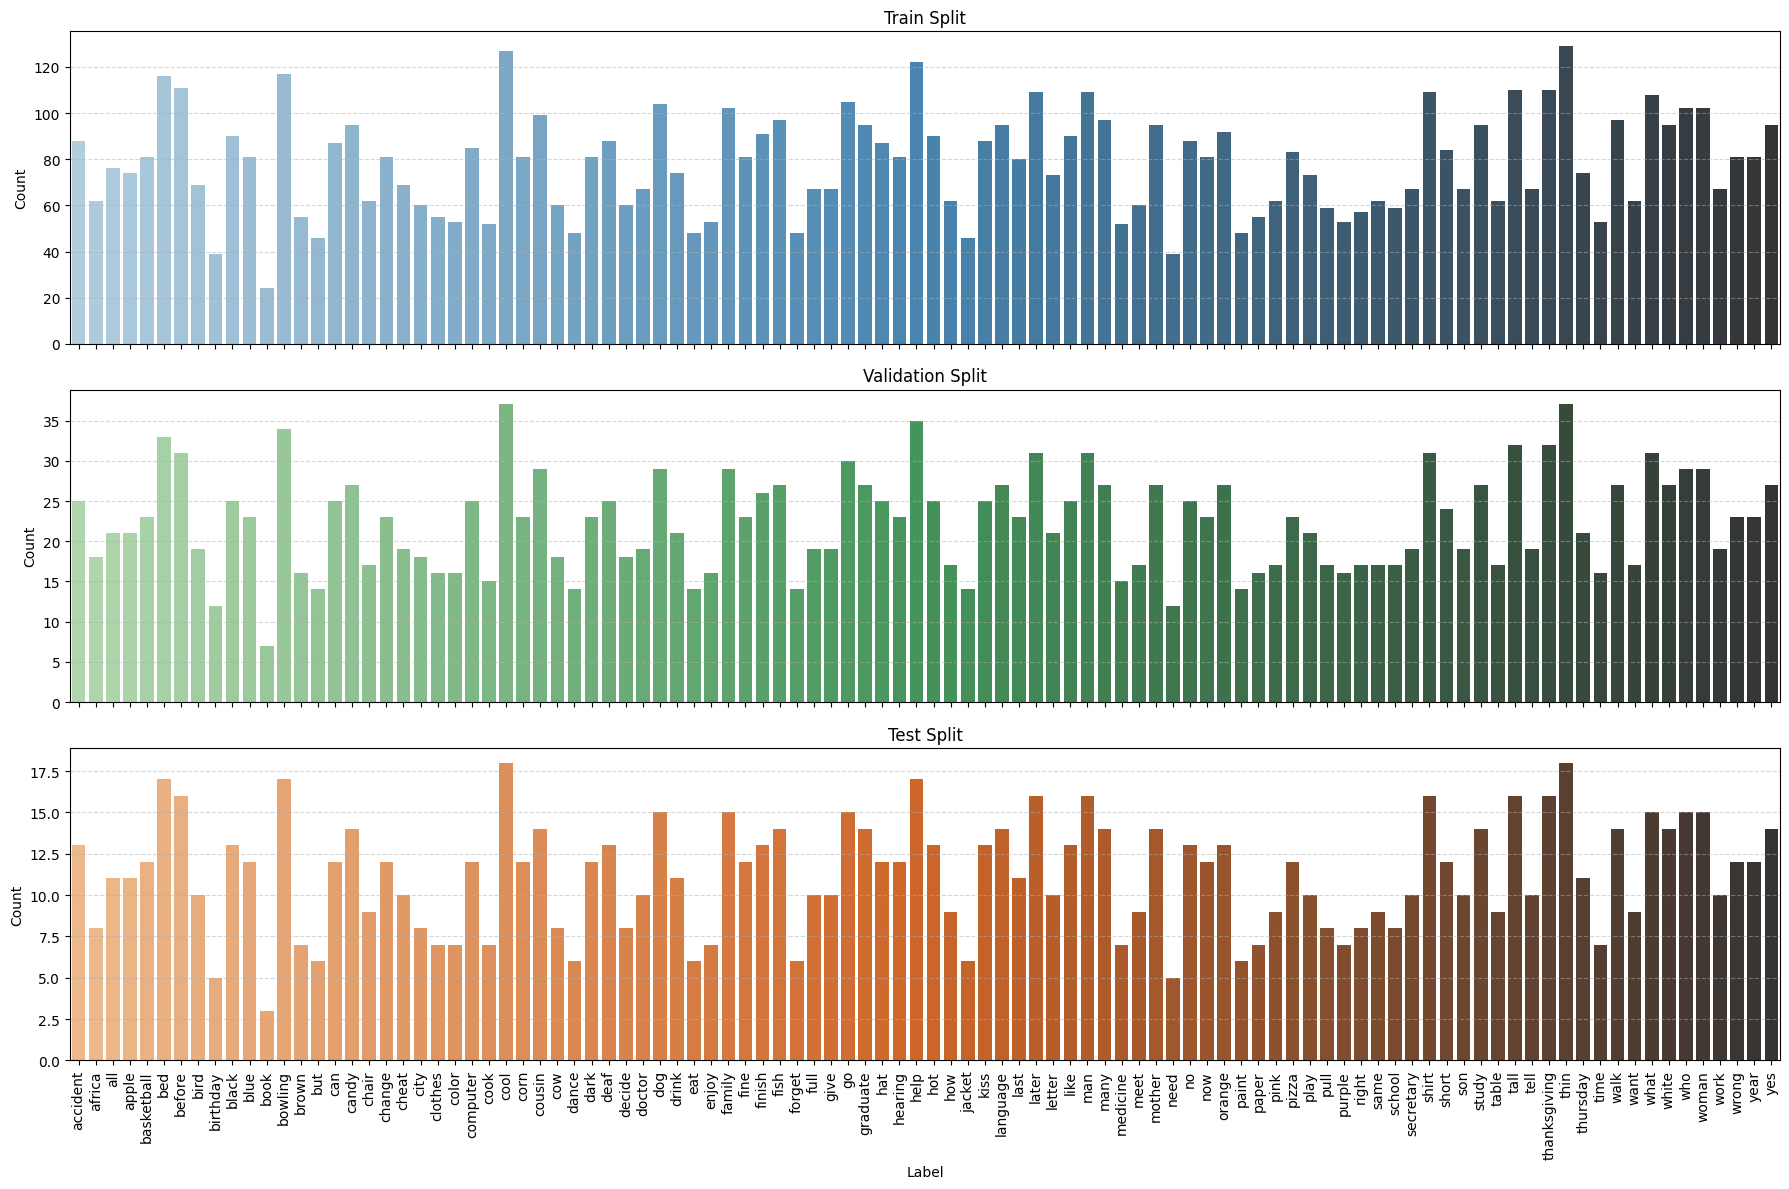

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)
idx_to_label = {v: k for k, v in label_to_idx.items()}

y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
y_val = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
y_test = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

def count_labels(y):
    counts = np.bincount(y, minlength=len(label_to_idx))
    return pd.DataFrame({
        "Label": [idx_to_label[i] for i in range(len(counts))],
        "Count": counts
    }).sort_values("Label")

df_train = count_labels(y_train)
df_val = count_labels(y_val)
df_test = count_labels(y_test)

def save_barplot(df, title, filename, color):
    plt.figure(figsize=(18, 24))
    sns.barplot(data=df, x="Label", y="Count", palette=color)
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.savefig(os.path.join(raw_frame_dir, filename))
    plt.close()

save_barplot(df_train, "Train Split: Videos per Label", "train_distribution.png", "Blues_d")
save_barplot(df_val, "Validation Split: Videos per Label", "val_distribution.png", "Greens_d")
save_barplot(df_test, "Test Split: Videos per Label", "test_distribution.png", "Oranges_d")

# --- Combined subplot figure ---
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

sns.barplot(data=df_train, x="Label", y="Count", ax=axes[0], palette="Blues_d")
axes[0].set_title("Train Split")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_val, x="Label", y="Count", ax=axes[1], palette="Greens_d")
axes[1].set_title("Validation Split")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_test, x="Label", y="Count", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Test Split")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Label")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(raw_frame_dir, "combined_distribution.png"))
plt.show()

# === Cell 6: Build TF Datasets ===

In [7]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from collections import Counter

# ---- Load Data ----

raw_frame_dir  = "/kaggle/working/frames_rgb"
label_map_path = os.path.join(raw_frame_dir, "label_to_idx.json")

X_train = np.load(os.path.join(raw_frame_dir, "X_train.npy"))
y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
X_val   = np.load(os.path.join(raw_frame_dir, "X_val.npy"))
y_val   = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
X_test  = np.load(os.path.join(raw_frame_dir, "X_test.npy"))
y_test  = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

with open(label_map_path, "r") as f:
    label_to_idx = json.load(f)

idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes  = len(label_to_idx)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

input_shape = X_train.shape[1:]   # e.g. (24, 64, 64, 1)
T, H, W, C  = input_shape

print(f"Input shape : {input_shape}  |  Classes: {num_classes}")



# ------ Dataset Pipelines -------

BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train_cat))
            .shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val_cat))
            .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test_cat))
            .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))

2026-04-04 08:10:18.162068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775290218.195767   15584 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775290218.206330   15584 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775290218.255076   15584 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775290218.255100   15584 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775290218.255103   15584 computation_placer.cc:177] computation placer alr

Input shape : (24, 64, 64, 1)  |  Classes: 100


I0000 00:00:1775290239.524569   15584 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775290239.529844   15584 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# === Cell 7: Data statistics ===

In [8]:
import numpy as np
import pandas as pd
from collections import defaultdict
import os

# --- Paths ---
raw_frame_dir = "/kaggle/working/frames_rgb"

# --- Initialize ---
class_counts = defaultdict(int)
frame_lengths = []

# --- Scan Saved .npy Files ---
for label in os.listdir(raw_frame_dir):
    label_path = os.path.join(raw_frame_dir, label)
    if not os.path.isdir(label_path):
        continue
    for fname in os.listdir(label_path):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(label_path, fname))
            class_counts[label] += 1
            frame_lengths.append(len(arr))

# --- Per-Class Stats ---
df_stats = pd.DataFrame({
    "Label": list(class_counts.keys()),
    "Valid Videos": list(class_counts.values())
}).sort_values("Valid Videos", ascending=False)

# --- Global Stats ---
global_stats = {
    "Total Classes": len(class_counts),
    "Total Valid Videos": sum(class_counts.values()),
    "Mean Frames per Video": np.mean(frame_lengths),
    "Median Frames per Video": np.median(frame_lengths),
    "Min Frames": np.min(frame_lengths),
    "Max Frames": np.max(frame_lengths),
}

# --- Output ---
print("=== Per-Class Statistics ===")
print(df_stats.to_string(index=False))

print("\n=== Global Statistics ===")
for k, v in global_stats.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

=== Per-Class Statistics ===
       Label  Valid Videos
        thin           184
        cool           182
        help           174
     bowling           168
         bed           166
      before           158
thanksgiving           158
        tall           158
       later           156
       shirt           156
         man           156
        what           154
          go           150
         dog           148
         who           146
      family           146
       woman           146
      cousin           142
        walk           138
        many           138
        fish           138
       white           136
      mother           136
    graduate           136
         yes           136
       study           136
    language           136
       candy           136
      orange           132
      finish           130
        like           128
       black           128
         hot           128
        kiss           126
          no           126

# === Cell 8: Imports ===

In [9]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Conv1D, GlobalAveragePooling1D, Dense, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

print("TF version:", tf.__version__)

TF version: 2.19.0


In [10]:

# — Helper 


def plot_history(history, title="Training"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],         label="train loss")
    axes[0].plot(history.history["val_loss"],     label="val loss")
    axes[0].set_title(f"{title} — Loss");         axes[0].legend()
    axes[1].plot(history.history["accuracy"],     label="train acc")
    axes[1].plot(history.history["val_accuracy"], label="val acc")
    axes[1].set_title(f"{title} — Accuracy");     axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ', '_')}.png")
    plt.show()

#   === Cell 9: Build Float32 Model ===

In [11]:
def build_s3d_conv1d_flat(input_shape, num_classes):
    T, H, W, C = input_shape
    H_out  = H // 4
    W_out  = W // 4
    C_flat = H_out * W_out * 24

    inputs = Input(shape=input_shape, name="video_input")

    # Merge time into spatial height: (B,T,H,W,C) → (B,T*H,W,C)
    x = Reshape((T * H, W, C), name="merge_time")(inputs)

    # Spatial CNN — inlined, no nested model
    x = Conv2D(12, (3,3), activation='relu', padding='same', name="conv2d_1")(x)
    x = MaxPooling2D((2,2), name="pool_1")(x)
    x = Conv2D(24, (3,3), activation='relu', padding='same', name="conv2d_2")(x)
    x = MaxPooling2D((2,2), name="pool_2")(x)

    # Split time back: (B,T*H_out,W_out,24) → (B,T,C_flat)
    x = Reshape((T, C_flat), name="split_time")(x)

    # Temporal Conv1D
    x = Conv1D(48, 3, padding='same', activation='relu',  # Ablation study with k=3 replaced with 1, 5, 7.
               name="temporal_conv1d")(x)
    x = GlobalAveragePooling1D(name="gap")(x)

    outputs = Dense(num_classes, activation='softmax',
                    name="classifier")(x)
    return Model(inputs, outputs, name="S3D_Conv1D_Flat")

float_model = build_s3d_conv1d_flat(input_shape, num_classes)
float_model.summary()

# Parameter / size preview
total_params    = float_model.count_params()
expected_f32_kb = total_params * 4 / 1024
expected_int8_kb = total_params * 1 / 1024
print(f"\nParameters       : {total_params:,}")
print(f"Expected Float32 : {expected_f32_kb:.1f} KB")
print(f"Expected INT8    : {expected_int8_kb:.1f} KB  "
      f"(theoretical {expected_f32_kb/expected_int8_kb:.0f}× reduction)")


Model: "S3D_Conv1D_Flat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 24, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ merge_time (Reshape)            │ (None, 1536, 64, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1536, 64, 12)   │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 768, 32, 12)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 768, 32, 24)    │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 384, 16, 24)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ split_time (Reshape)            │ (None, 24, 6144)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv1d (Conv1D)        │ (None, 24, 48)         │       884,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 100)            │         4,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 892,420 (3.40 MB)

 Trainable params: 892,420 (3.40 MB)

 Non-trainable params: 0 (0.00 B)


Parameters       : 892,420
Expected Float32 : 3486.0 KB
Expected INT8    : 871.5 KB  (theoretical 4× reduction)


#  === Cell 10: Train Float32 Model ===


>>> Float32 Training <<<

Epoch 1/100


I0000 00:00:1775290286.063769   29730 service.cc:152] XLA service 0x7bef0c08b9a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775290286.063809   29730 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775290286.063813   29730 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775290286.568943   29730 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/245 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.0025 - loss: 4.6996     

I0000 00:00:1775290292.375849   29730 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0141 - loss: 4.6146
Epoch 1: val_accuracy improved from -inf to 0.02769, saving model to /kaggle/working/ptq_float_model_best.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.0141 - loss: 4.6144 - val_accuracy: 0.0277 - val_loss: 4.5097 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0341 - loss: 4.4304
Epoch 2: val_accuracy improved from 0.02769 to 0.07369, saving model to /kaggle/working/ptq_float_model_best.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.0342 - loss: 4.4301 - val_accuracy: 0.0737 - val_loss: 4.1690 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0899 - loss: 4.0299
Epoch 3: val_accuracy improved from 0.07369 to 0.12640, saving model to /kaggle/working/ptq_float_model_best.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.0900 - loss: 4.0294 - val_accuracy: 0.1264 - val_loss: 3.7581 - l

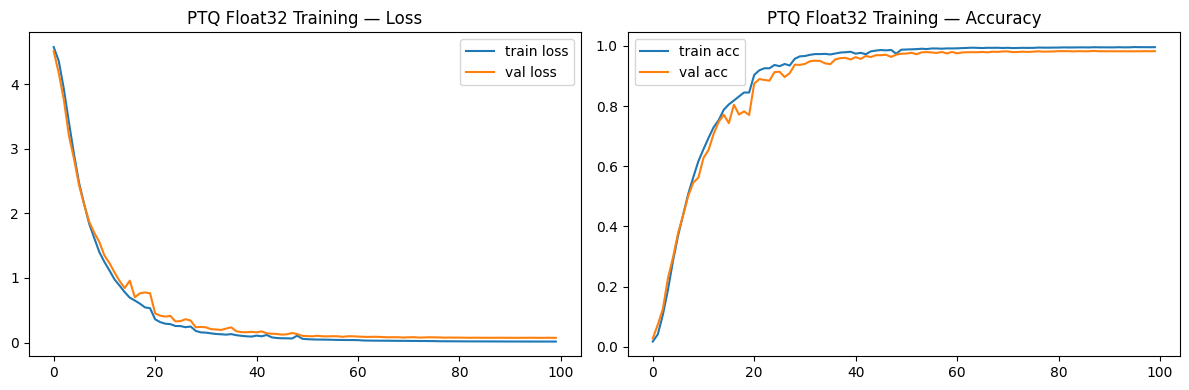


Float32 Test → loss: 0.1015  |  acc: 0.9723


In [12]:
float_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/ptq_float_model_best.keras",
        save_best_only=True, monitor="val_accuracy", verbose=1
    )
]

print("\n>>> Float32 Training <<<\n")
history = float_model.fit(
    train_ds, epochs=100,
    validation_data=val_ds,
    callbacks=callbacks
)

plot_history(history, title="PTQ Float32 Training")

float_loss, float_acc = float_model.evaluate(test_ds, verbose=0)
print(f"\nFloat32 Test → loss: {float_loss:.4f}  |  acc: {float_acc:.4f}")

# === Cell 11: Classification report & confusion matrix ===

=== Classification report & confusion matrix ===
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Classification report saved: /kaggle/working/classification_report.csv
              precision    recall  f1-score   support

        book       1.00      1.00      1.00         3
       drink       1.00      1.00      1.00        11
    computer       1.00      0.92      0.96        12
      before       1.00      0.88      0.93        16
       chair       1.00      1.00      1.00         9
          go       0.94      1.00      0.97        15
     clothes       1.00      1.00      1.00         7
         who       0.94      1.00      0.97        15
       candy       0.93      1.00      0.97        14
      cousin       1.00      1.00      1.00        14
        deaf       1.00      1.00      1.00        13
        fine       1.00      1.00      1.00        12
        help       1.00      1.00      1.00        17
          no       1.00      1.00      1.00        13
        thin       1.00      

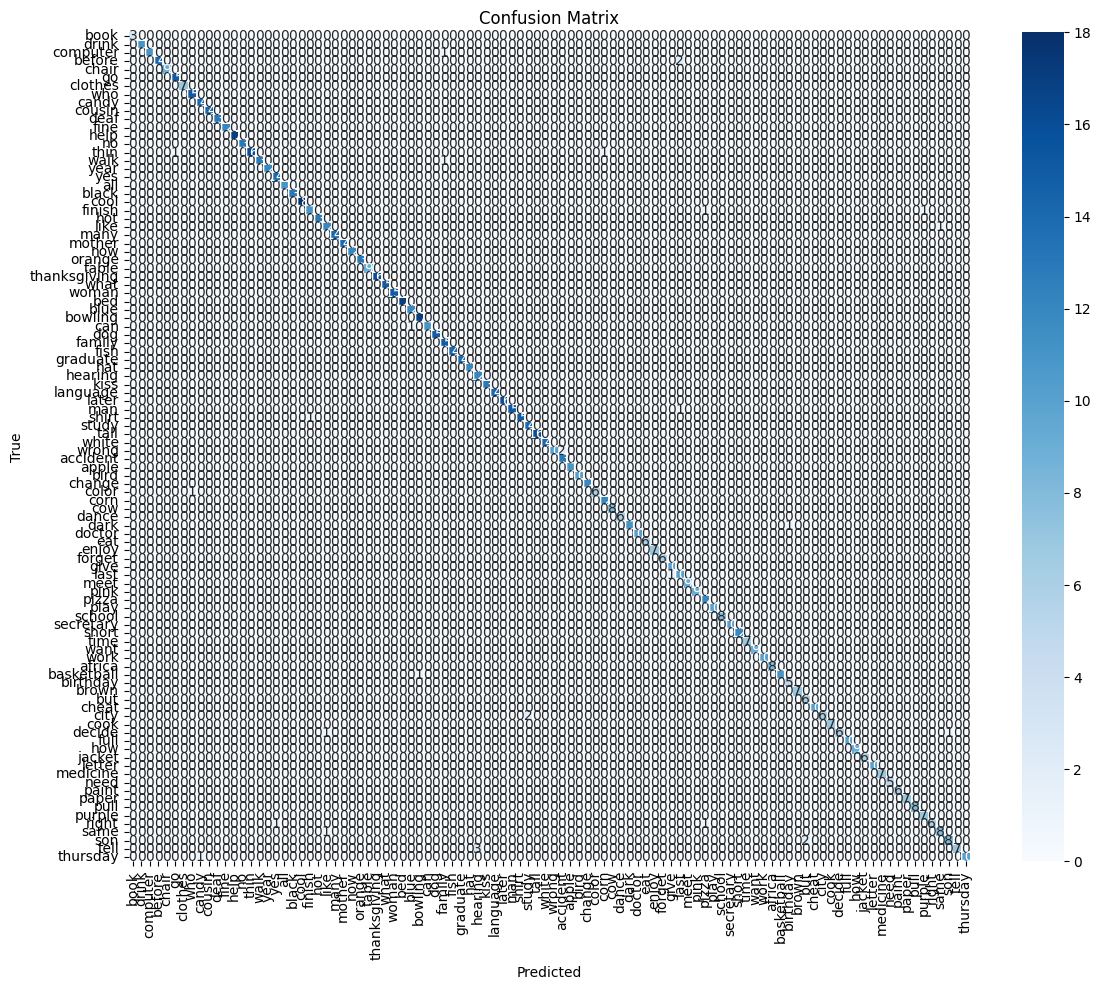

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("=== Classification report & confusion matrix ===")

# Predictions
y_probs = float_model.predict(test_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = y_test[:len(y_pred)]

# Label names
target_names = [lbl for lbl, _ in sorted(label_to_idx.items(), key=lambda x: x[1])]

# Define output paths
REPORT_PATH = "/kaggle/working/classification_report.csv"
CONFUSION_MATRIX_PATH = "/kaggle/working/confusion_matrix.npy"

# Classification report
report_dict = classification_report(
    y_true, y_pred,
    target_names=target_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORT_PATH, index=True)
print(f"Classification report saved: {REPORT_PATH}")
print(classification_report(y_true, y_pred, target_names=target_names))

# Top / bottom 5 by F1
summary = report_df.iloc[:-3].sort_values("f1-score", ascending=False)
print("\n Top 5 by F1:")
print(summary.head(5)[["precision", "recall", "f1-score", "support"]].round(2).to_string())
print("\n Bottom 5 by F1:")
print(summary.tail(5)[["precision", "recall", "f1-score", "support"]].round(2).to_string())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
np.save(CONFUSION_MATRIX_PATH, cm)
print(f"Confusion matrix saved: {CONFUSION_MATRIX_PATH}")

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()




#  === Cell 12: PTQ: Convert to TFLite INT8 ===

In [15]:
# ── Float32 TFLite ───────────────────────
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(float_model)
tflite_f32    = converter_f32.convert()
f32_path      = "/kaggle/working/ptq_float32.tflite"
with open(f32_path, "wb") as f:
    f.write(tflite_f32)

# ── INT8 PTQ conversion ───────────────────────────────────────────────────────
def representative_dataset():
    """
    Feed real training samples so the converter can observe the true
    activation distributions for each layer. More samples = more accurate
    scale/zero_point calibration. 100 batches is sufficient.
    """
    for x_batch, _ in train_ds.take(500):
        for sample in x_batch:
            yield [tf.expand_dims(tf.cast(sample, tf.float32), axis=0)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(float_model)
converter_int8.optimizations            = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset  = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type    = tf.int8
converter_int8.inference_output_type   = tf.int8
converter_int8.experimental_new_converter = True   # MLIR — better flat graph handling

tflite_int8 = converter_int8.convert()
int8_path   = "/kaggle/working/ptq_int8.tflite"
with open(int8_path, "wb") as f:
    f.write(tflite_int8)

print(f"Float32 TFLite : {os.path.getsize(f32_path)/1024:.1f} KB → {f32_path}")
print(f"INT8 PTQ TFLite: {os.path.getsize(int8_path)/1024:.1f} KB → {int8_path}")

INFO:tensorflow:Assets written to: /tmp/tmp268a38_3/assets


INFO:tensorflow:Assets written to: /tmp/tmp268a38_3/assets


Saved artifact at '/tmp/tmp268a38_3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 64, 64, 1), dtype=tf.float32, name='video_input')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  136272634261584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634262160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634261776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634265424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136276814890000: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775291274.029330   15584 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775291274.029364   15584 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775291274.036801   15584 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


INFO:tensorflow:Assets written to: /tmp/tmp0odku0br/assets


INFO:tensorflow:Assets written to: /tmp/tmp0odku0br/assets


Saved artifact at '/tmp/tmp0odku0br'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 64, 64, 1), dtype=tf.float32, name='video_input')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  136272634261584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634262160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634261776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634264656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136272634265424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136276814890000: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775291274.913263   15584 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775291274.913296   15584 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Float32 TFLite : 3492.2 KB → /kaggle/working/ptq_float32.tflite
INT8 PTQ TFLite: 883.1 KB → /kaggle/working/ptq_int8.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


# === Cell 13: PTQ Quantization Parameters ===

In [16]:
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
all_tensors    = interpreter.get_tensor_details()

# Reconstruct x_min / x_max from scale & zero_point
rows = []
for t in all_tensors:
    scale, zero_point = t.get("quantization", (0.0, 0))
    if scale > 0:
        x_min = -zero_point * scale
        x_max = x_min + scale * 255
        rows.append({
            "index"      : t["index"],
            "name"       : t["name"],
            "dtype"      : str(t["dtype"]),
            "scale"      : round(float(scale), 8),
            "zero_point" : int(zero_point),
            "x_min"      : round(float(x_min), 6),
            "x_max"      : round(float(x_max), 6),
        })

df_quant = pd.DataFrame(rows)
print("\n" + "="*80)
print("  PTQ QUANTIZATION PARAMETERS — all quantized tensors")
print("="*80)
display(df_quant)

df_quant.to_csv("/kaggle/working/ptq_quantization_params.csv", index=False)



  PTQ QUANTIZATION PARAMETERS — all quantized tensors


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,index,name,dtype,scale,zero_point,x_min,x_max
0,0,serving_default_video_input:0,<class 'numpy.int8'>,0.003922,-128,0.501961,1.501961
1,21,S3D_Conv1D_Flat_1/merge_time_1/Reshape,<class 'numpy.int8'>,0.003922,-128,0.501961,1.501961
2,22,S3D_Conv1D_Flat_1/conv2d_1_1/Relu;S3D_Conv1D_F...,<class 'numpy.int8'>,0.040306,-128,5.159186,15.437252
3,23,S3D_Conv1D_Flat_1/pool_1_1/MaxPool2d,<class 'numpy.int8'>,0.040306,-128,5.159186,15.437252
4,24,S3D_Conv1D_Flat_1/conv2d_2_1/Relu;S3D_Conv1D_F...,<class 'numpy.int8'>,0.162197,-128,20.761274,62.121626
5,25,S3D_Conv1D_Flat_1/pool_2_1/MaxPool2d,<class 'numpy.int8'>,0.162197,-128,20.761274,62.121626
6,29,S3D_Conv1D_Flat_1/split_time_1/Reshape,<class 'numpy.int8'>,0.162197,-128,20.761274,62.121626
7,30,S3D_Conv1D_Flat_1/temporal_conv1d_1/convolutio...,<class 'numpy.int8'>,0.162197,-128,20.761274,62.121626
8,31,S3D_Conv1D_Flat_1/temporal_conv1d_1/Relu;S3D_C...,<class 'numpy.int8'>,4.497750,-128,575.712036,1722.638358
9,32,S3D_Conv1D_Flat_1/temporal_conv1d_1/Relu;S3D_C...,<class 'numpy.int8'>,4.497750,-128,575.712036,1722.638358


#  === Cell 14: INT8 Inference + Evaluation ===

In [17]:
def preprocess_input(x):
    scale, zero_point = input_details[0]["quantization"]
    return (x / scale + zero_point).astype(np.int8)

def dequantize_output(x):
    scale, zero_point = output_details[0]["quantization"]
    return (x.astype(np.float32) - zero_point) * scale

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)

print("Running INT8 inference on test set...")
y_probs = []
for x in X_test:
    x_in  = preprocess_input(x[np.newaxis, ...])
    interpreter.set_tensor(input_details[0]["index"], x_in)
    interpreter.invoke()
    out   = interpreter.get_tensor(output_details[0]["index"])
    y_probs.append(softmax(dequantize_output(out)[0]))

y_probs = np.array(y_probs)
y_pred  = np.argmax(y_probs, axis=1)
ptq_acc = np.mean(y_pred == y_test)

print(f"\nPTQ INT8 Test Accuracy: {ptq_acc*100:.2f}%")
print(f"Float32 Test Accuracy : {float_acc*100:.2f}%")
print(f"Accuracy drop         : {(float_acc - ptq_acc)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Running INT8 inference on test set...

PTQ INT8 Test Accuracy: 89.55%
Float32 Test Accuracy : 97.23%
Accuracy drop         : 7.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       0.92      1.00      0.96        11
           2       0.92      0.92      0.92        12
           3       0.59      1.00      0.74        16
           4       0.90      1.00      0.95         9
           5       0.93      0.87      0.90        15
           6       0.78      1.00      0.88         7
           7       0.75      1.00      0.86        15
           8       0.88      1.00      0.93        14
           9       1.00      0.93      0.96        14
          10       0.81      1.00      0.90        13
          11       0.73      0.92      0.81        12
          12       0.94      1.00      0.97        17
          13       0.92      0.92      0.92        13
          14       0.84      0.89 

# === Cell 15: Top-20 Error Heatmap (PTQ INT8) ===

Total errors  : 117
Total samples : 1120
Error rate    : 10.45%

Top 20 most frequent (true → predicted) errors:
───────────────────────────────────────────────────────
   1. [  3×]  'last'  →  'before'
   2. [  3×]  'tell'  →  'orange'
   3. [  2×]  'want'  →  'walk'
   4. [  2×]  'secretary'  →  'accident'
   5. [  2×]  'orange'  →  'who'
   6. [  2×]  'basketball'  →  'before'
   7. [  2×]  'what'  →  'orange'
   8. [  2×]  'forget'  →  'black'
   9. [  2×]  'city'  →  'study'
  10. [  2×]  'son'  →  'but'
  11. [  2×]  'shirt'  →  'finish'
  12. [  2×]  'go'  →  'before'
  13. [  2×]  'full'  →  'fish'
  14. [  2×]  'how'  →  'family'
  15. [  2×]  'apple'  →  'bowling'
  16. [  2×]  'purple'  →  'woman'
  17. [  2×]  'secretary'  →  'year'
  18. [  2×]  'bed'  →  'cool'
  19. [  1×]  'full'  →  'white'
  20. [  1×]  'what'  →  'book'


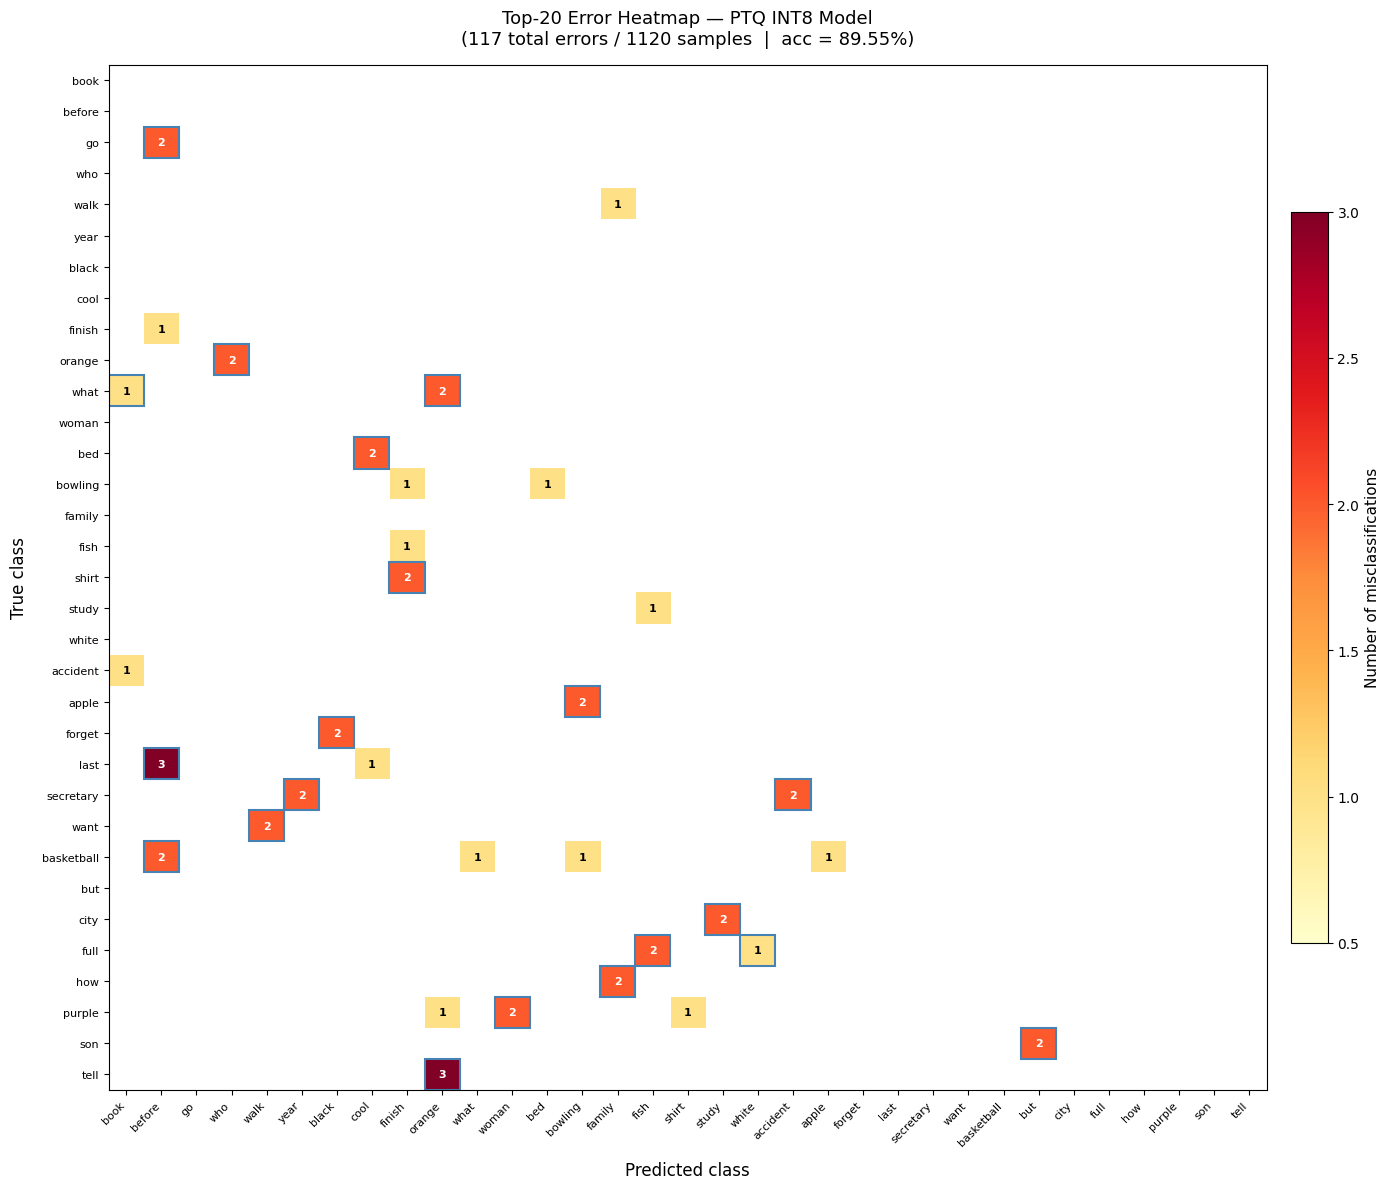

Saved → /kaggle/working/ptq_top20_error_heatmap.png

  PER-CLASS ERROR RATE (classes in top-20 errors)
  Class                       Total  Errors    Err %
────────────────────────────────────────────────────────────
  book                            3       0     0.0%  
  before                         16       0     0.0%  
  go                             15       2    13.3%  ██████
  who                            15       0     0.0%  
  walk                           14       1     7.1%  ███
  year                           12       0     0.0%  
  black                          13       1     7.7%  ███
  cool                           18       0     0.0%  
  finish                         13       1     7.7%  ███
  orange                         13       2    15.4%  ███████
  what                           15       4    26.7%  █████████████
  woman                          15       1     6.7%  ███
  bed                            17       2    11.8%  █████
  bowling                

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── Step 1: Find top-20 most frequent errors ──────────────────────────────────
errors       = [(t, p) for t, p in zip(y_test, y_pred) if t != p]
error_counts = Counter(errors)
top20_errors = error_counts.most_common(20)

print(f"Total errors  : {len(errors)}")
print(f"Total samples : {len(y_test)}")
print(f"Error rate    : {len(errors)/len(y_test)*100:.2f}%")

print(f"\nTop 20 most frequent (true → predicted) errors:")
print("─" * 55)
for rank, ((t, p), count) in enumerate(top20_errors, 1):
    t_label = idx_to_label.get(t, str(t))
    p_label = idx_to_label.get(p, str(p))
    print(f"  {rank:2d}. [{count:3d}×]  '{t_label}'  →  '{p_label}'")

# ── Step 2: Build sub-matrix for involved classes ─────────────────────────────
involved_classes = sorted(set(
    cls for pair, _ in top20_errors for cls in pair
))
n            = len(involved_classes)
class_labels = [idx_to_label.get(c, str(c)) for c in involved_classes]
cls_to_idx   = {c: i for i, c in enumerate(involved_classes)}

sub_matrix = np.zeros((n, n), dtype=int)
for (t, p), count in error_counts.items():
    if t in cls_to_idx and p in cls_to_idx:
        sub_matrix[cls_to_idx[t], cls_to_idx[p]] += count

np.fill_diagonal(sub_matrix, 0)   # focus on errors only

# ── Step 3: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

cmap = plt.cm.YlOrRd
cmap.set_under("white")

im = ax.imshow(sub_matrix, cmap=cmap, vmin=0.5,
               vmax=sub_matrix.max(), aspect="auto")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Number of misclassifications", fontsize=11)

for i in range(n):
    for j in range(n):
        val = sub_matrix[i, j]
        if val > 0:
            text_color = "white" if val > sub_matrix.max() * 0.6 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=8, fontweight="bold", color=text_color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(class_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(class_labels, fontsize=8)
ax.set_xlabel("Predicted class", fontsize=12, labelpad=10)
ax.set_ylabel("True class",      fontsize=12, labelpad=10)
ax.set_title(
    f"Top-20 Error Heatmap — PTQ INT8 Model\n"
    f"({len(errors)} total errors / {len(y_test)} samples  |  "
    f"acc = {(1 - len(errors)/len(y_test))*100:.2f}%)",
    fontsize=13, pad=15
)

for rank, ((t, p), count) in enumerate(top20_errors):
    if t in cls_to_idx and p in cls_to_idx:
        ax.add_patch(plt.Rectangle(
            (cls_to_idx[p] - 0.5, cls_to_idx[t] - 0.5), 1, 1,
            linewidth=1.5, edgecolor="steelblue", facecolor="none"
        ))

plt.tight_layout()
plt.savefig("/kaggle/working/ptq_top20_error_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/ptq_top20_error_heatmap.png")

# ── Step 4: Per-class error rate ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PER-CLASS ERROR RATE (classes in top-20 errors)")
print("=" * 60)
print(f"  {'Class':<25s}  {'Total':>6s}  {'Errors':>6s}  {'Err %':>7s}")
print("─" * 60)
for c in involved_classes:
    label    = idx_to_label.get(c, str(c))
    total    = int((y_test == c).sum())
    n_errors = int(((y_test == c) & (y_pred != c)).sum())
    err_rate = n_errors / total * 100 if total > 0 else 0
    bar      = "█" * int(err_rate / 2)
    print(f"  {label:<25s}  {total:>6d}  {n_errors:>6d}  "
          f"{err_rate:>6.1f}%  {bar}")

# === Cell 16: Size Comparison Summary ===

In [19]:
f32_kb  = os.path.getsize(f32_path) / 1024
int8_kb = os.path.getsize(int8_path) / 1024

print("\n" + "=" * 55)
print("   PTQ MODEL SIZE COMPARISON")
print("=" * 55)
print(f"  Float32 TFLite : {f32_kb:>8.1f} KB")
print(f"  INT8 PTQ TFLite: {int8_kb:>8.1f} KB")
print(f"  Size reduction : {(1 - int8_kb/f32_kb)*100:.1f}%")
print(f"  Ratio          : {f32_kb/int8_kb:.1f}×")
print("=" * 55)

# Check tensor dtype coverage
int8_count  = sum(1 for t in all_tensors if t["dtype"] == np.int8)
f32_count   = sum(1 for t in all_tensors if t["dtype"] == np.float32)
print(f"\n  INT8 tensors  : {int8_count}  ✓")
print(f"  Float32 tensors: {f32_count}  "
      + ("✓ (expected — non-quantizable ops)" if f32_count < 5
         else "⚠  high — TimeDistributed may still be present"))


   PTQ MODEL SIZE COMPARISON
  Float32 TFLite :   3492.2 KB
  INT8 PTQ TFLite:    883.1 KB
  Size reduction : 74.7%
  Ratio          : 4.0×

  INT8 tensors  : 17  ✓
  Float32 tensors: 0  ✓ (expected — non-quantizable ops)


#  === Cell 17: Save All Outputs ===

   PTQ NOTEBOOK — OUTPUT FILES
  Description                                Size  Status
──────────────────────────────────────────────────────────────
  Float32 Keras checkpoint              10502.8 KB  ✓
  Float32 TFLite                         3492.2 KB  ✓
  INT8 PTQ TFLite                         883.1 KB  ✓
  Quantization params CSV                   1.9 KB  ✓
  Training curves                          41.4 KB  ✓
  Top-20 error heatmap                    149.5 KB  ✓
──────────────────────────────────────────────────────────────
  Total..............................   15070.8 KB

  ✓  All outputs saved. Download from the Output tab →

  DEPLOYMENT-RELEVANT COMPARISON
  ──────────────────────────────────────────────────
  Float32 TFLite  :   3492.2 KB
  INT8 PTQ TFLite :    883.1 KB
  ──────────────────────────────────────────────────
  Size reduction  : 74.7%
  Compression ratio: 4.0×
  Accuracy (float): 97.23%
  Accuracy (INT8) : 89.55%
  Accuracy drop   : 7.68%
  ────────────────

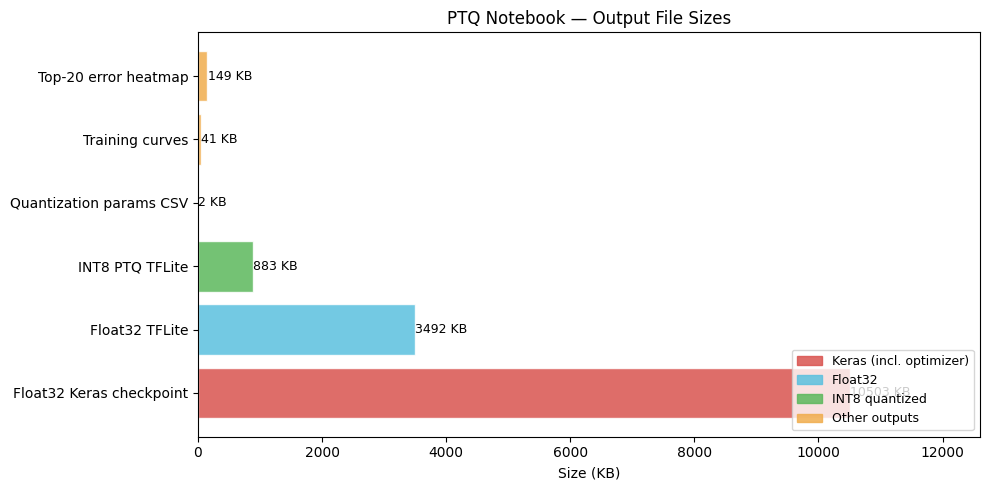


  All files are in: /kaggle/working
  In Kaggle: click the Output tab (top right) → download any file.


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUTPUT_DIR = "/kaggle/working"

# ── All output files produced by this notebook ────────────────────────────────
output_files = {
    # Models
    "Float32 Keras checkpoint"  : "ptq_float_model_best.keras",
    "Float32 TFLite"            : "ptq_float32.tflite",
    "INT8 PTQ TFLite"           : "ptq_int8.tflite",
    # Data
    "Quantization params CSV"   : "ptq_quantization_params.csv",
    # Plots
    "Training curves"           : "PTQ_Float32_Training.png",
    "Top-20 error heatmap"      : "ptq_top20_error_heatmap.png",
}

print("=" * 62)
print("   PTQ NOTEBOOK — OUTPUT FILES")
print("=" * 62)
print(f"  {'Description':<35s}  {'Size':>10s}  {'Status'}")
print("─" * 62)

total_kb = 0
all_ok   = True
for desc, fname in output_files.items():
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        kb = os.path.getsize(path) / 1024
        total_kb += kb
        print(f"  {desc:<35s}  {kb:>8.1f} KB  ✓")
    else:
        print(f"  {desc:<35s}  {'missing':>10s}  ✗")
        all_ok = False

print("─" * 62)
print(f"  {'Total':.<35s}  {total_kb:>8.1f} KB")
print("=" * 62)

if all_ok:
    print("\n  ✓  All outputs saved. Download from the Output tab →")
else:
    print("\n  ⚠  Some files missing — check cells above for errors.")

# ── Deployment-relevant size comparison (matches QAT Cell 11 format) ─────────
f32_path  = os.path.join(OUTPUT_DIR, "ptq_float32.tflite")
int8_path = os.path.join(OUTPUT_DIR, "ptq_int8.tflite")

if os.path.exists(f32_path) and os.path.exists(int8_path):
    f32_kb  = os.path.getsize(f32_path)  / 1024
    int8_kb = os.path.getsize(int8_path) / 1024

    print(f"""
  DEPLOYMENT-RELEVANT COMPARISON
  ──────────────────────────────────────────────────
  Float32 TFLite  : {f32_kb:>8.1f} KB
  INT8 PTQ TFLite : {int8_kb:>8.1f} KB
  ──────────────────────────────────────────────────
  Size reduction  : {(1 - int8_kb/f32_kb)*100:.1f}%
  Compression ratio: {f32_kb/int8_kb:.1f}×
  Accuracy (float): {float_acc*100:.2f}%
  Accuracy (INT8) : {ptq_acc*100:.2f}%
  Accuracy drop   : {(float_acc - ptq_acc)*100:.2f}%
  ──────────────────────────────────────────────────""")

# ── Bar chart: all output file sizes ─────────────────────────────────────────
existing = {desc: os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1024
            for desc, fname in output_files.items()
            if os.path.exists(os.path.join(OUTPUT_DIR, fname))}

colors = ["#d9534f" if "Keras" in d
          else "#5bc0de" if "Float32" in d
          else "#5cb85c" if "INT8" in d
          else "#f0ad4e" for d in existing]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(existing.keys()), list(existing.values()),
               color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, existing.values()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f} KB", va="center", fontsize=9)

legend_patches = [
    mpatches.Patch(color="#d9534f", alpha=0.85, label="Keras (incl. optimizer)"),
    mpatches.Patch(color="#5bc0de", alpha=0.85, label="Float32"),
    mpatches.Patch(color="#5cb85c", alpha=0.85, label="INT8 quantized"),
    mpatches.Patch(color="#f0ad4e", alpha=0.85, label="Other outputs"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.set_xlabel("Size (KB)")
ax.set_title("PTQ Notebook — Output File Sizes")
ax.set_xlim(0, max(existing.values()) * 1.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ptq_output_sizes.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  All files are in: {OUTPUT_DIR}")
print("  In Kaggle: click the Output tab (top right) → download any file.")